<a href="https://colab.research.google.com/github/ParushiSrivastava/PARUSHI.23FE10CSE00380/blob/main/disease_pridiction_mlLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub scikit-image

In [ ]:
import os
import cv2
import numpy as np
import joblib

from tqdm import tqdm

from skimage.feature import hog

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset downloaded at:", dataset_path)

base_dir = os.path.join(
    dataset_path,
    "plantvillage dataset/color"
)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded at: /kaggle/input/plantvillage-dataset


In [ ]:
import cv2
import numpy as np
from skimage.feature import hog

def extract_features(image):

    # Resize image
    image = cv2.resize(
        image,
        (128,128)
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # -------- HOG Features --------

    hog_features = hog(

        gray,

        orientations=9,

        pixels_per_cell=(8,8),

        cells_per_block=(2,2),

        block_norm='L2-Hys'
    )


    # -------- Color Histogram --------

    color_features = []

    for i in range(3):  # BGR channels

        hist = cv2.calcHist(

            [image],

            [i],

            None,

            [32],

            [0,256]
        )

        hist = cv2.normalize(
            hist,
            hist
        ).flatten()

        color_features.extend(hist)


    # -------- Combine Features --------

    final_features = np.hstack([

        hog_features,

        color_features

    ])

    return final_features

In [ ]:
X = []
y = []

classes = os.listdir(base_dir)

max_images_per_class = 120   # increase if GPU time allows

for class_name in classes:

    class_path = os.path.join(
        base_dir,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)[
        :max_images_per_class
    ]

    for img_name in tqdm(images):

        img_path = os.path.join(
            class_path,
            img_name
        )

        image = cv2.imread(img_path)

        if image is None:
            continue

        features = extract_features(
            image
        )

        X.append(features)
        y.append(class_name)

print("Feature extraction completed")

100%|██████████| 120/120 [00:00<00:00, 133.14it/s]

Feature extraction completed


In [ ]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Labels encoded")

Labels encoded


In [ ]:
scaler = StandardScaler()

X = np.array(X)

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")

Feature scaling completed


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y_encoded,

    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define Models

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=3000,
        n_jobs=-1
    ),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1
    ),

    "SVM":
    SVC(),

    "KNN":
    KNeighborsClassifier(),

    "Naive Bayes":
    GaussianNB()

}

model_names = []
model_accuracies = []

print("Training Models...\n")

for name, model in models.items():

    print("Training:", name)

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print(
        name,
        "Accuracy:",
        accuracy
    )

    print("------------------")

    model_names.append(name)

    model_accuracies.append(accuracy)

Training Models...

Training: Logistic Regression
Logistic Regression Accuracy: 0.6129385964912281
------------------
Training: Decision Tree
Decision Tree Accuracy: 0.27960526315789475
------------------
Training: Random Forest
Random Forest Accuracy: 0.5734649122807017
------------------
Training: SVM
SVM Accuracy: 0.5997807017543859
------------------
Training: KNN
KNN Accuracy: 0.32894736842105265
------------------
Training: Naive Bayes
Naive Bayes Accuracy: 0.5756578947368421
------------------


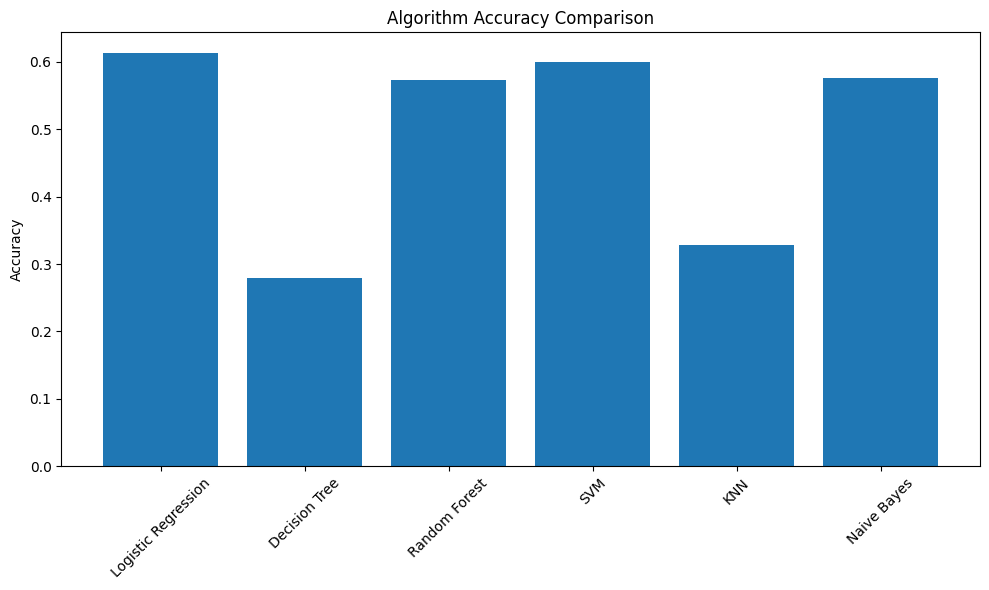

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    model_names,
    model_accuracies
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Algorithm Accuracy Comparison")

plt.tight_layout()

plt.show()

In [ ]:
best_index = model_accuracies.index(
    max(model_accuracies)
)

best_model_name = model_names[best_index]

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    model_accuracies[best_index]
)

final_model = models[best_model_name]

Best Model: Logistic Regression
Best Accuracy: 0.6129385964912281


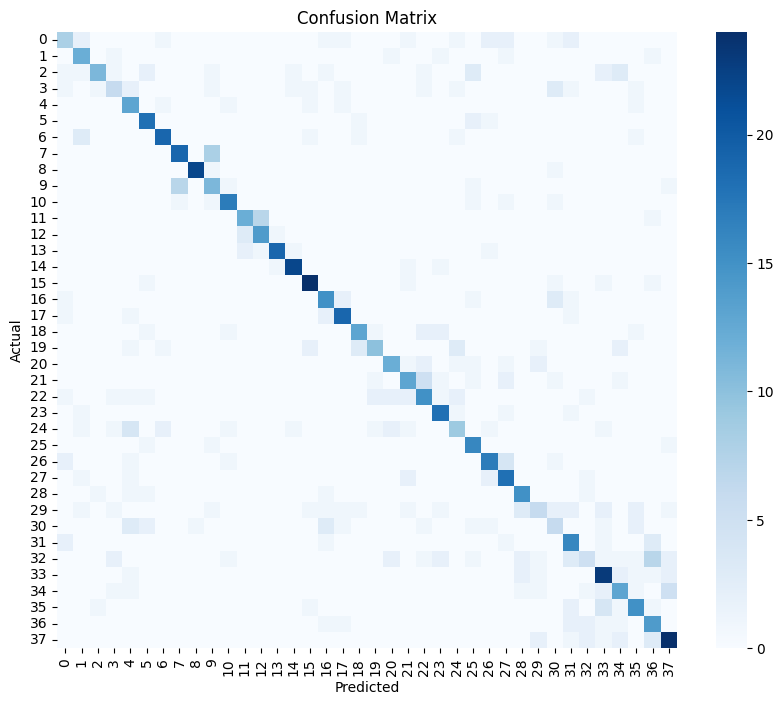

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_final = final_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

joblib.dump(
    final_model,
    "plant_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

print("Model saved successfully")

Model saved successfully


Upload a leaf image


Saving test_apple_black_rot.JPG to test_apple_black_rot.JPG


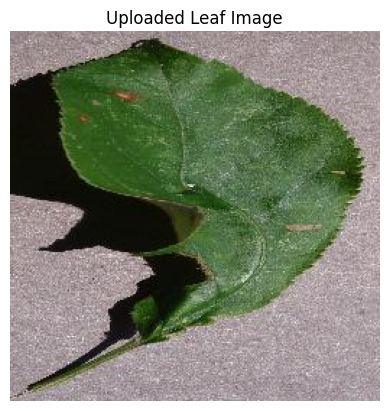


🌿 Predicted Disease: Apple___Black_rot


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2

print("Upload a leaf image")

uploaded = files.upload()

if len(uploaded) == 0:

    print("No image uploaded")

else:

    test_image = list(uploaded.keys())[0]

    image = cv2.imread(
        test_image
    )

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Show Image
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Uploaded Leaf Image")
    plt.show()


    # Extract Features
    features = extract_features(
        image
    )

    scaler = joblib.load("scaler.pkl")

    model = joblib.load("plant_model.pkl")

    encoder = joblib.load("label_encoder.pkl")


    features_scaled = scaler.transform(
        [features]
    )

    prediction = model.predict(
        features_scaled
    )

    predicted_label = encoder.inverse_transform(
        prediction
    )

    print(
        "\n🌿 Predicted Disease:",
        predicted_label[0]
    )